In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df = pd.read_csv('dataset2.csv')

In [3]:
bins = range(0, int(df['final_price_usd'].max()) + 25, 25)
df['price_range'] = pd.cut(df['final_price_usd'], bins=bins)


📊 Units Sold by Price Range:

  price_range  units_sold
0    (25, 50]        1188
1    (50, 75]       11973
2   (75, 100]       13837
3  (100, 125]       13621
4  (125, 150]       13614
5  (150, 175]       11503
6  (175, 200]        7057
7  (200, 225]        2213


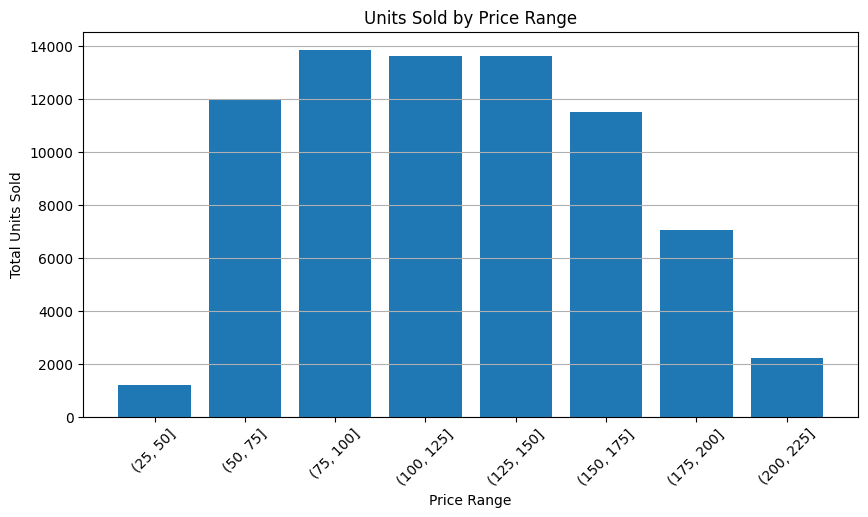

In [4]:
import matplotlib.pyplot as plt

units_grouped = df.groupby('price_range')['units_sold'].sum().reset_index()
units_grouped = units_grouped.sort_values(by='price_range')

print("\n📊 Units Sold by Price Range:\n")
print(units_grouped)

plt.figure(figsize=(10,5))
plt.bar(units_grouped['price_range'].astype(str), units_grouped['units_sold'])
plt.xlabel('Price Range')
plt.ylabel('Total Units Sold')
plt.title('Units Sold by Price Range')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## Hypothesis Test: Price Range Effect on Orders

**Null Hypothesis (H0):** There is no difference in the number of orders across price groups (Low, Mid, High).

**Alternative Hypothesis (H1):** At least one price group has significantly different order counts.

**Test Method:** One-way ANOVA with post-hoc t-tests to identify which groups differ.

In [5]:
import pandas as pd
from scipy.stats import f_oneway, ttest_ind

def price_group(p):
    if p < 75:
        return 'Low'
    elif p <= 150:
        return 'Mid'
    else:
        return 'High'

df['price_group'] = df['final_price_usd'].apply(price_group)

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['year'] = df['order_date'].dt.year

grouped = df.groupby(['year', 'price_group'])['order_id'].count().reset_index()

low = grouped[grouped['price_group'] == 'Low']['order_id']
mid = grouped[grouped['price_group'] == 'Mid']['order_id']
high = grouped[grouped['price_group'] == 'High']['order_id']
print(low,mid,high)

f_stat, p_anova = f_oneway(low, mid, high)

print("===== ANOVA RESULT =====")
print("F-statistic:", f_stat)
print("P-value:", p_anova)

alpha = 0.05

if p_anova < alpha:
    print("\nReject Null Hypothesis (H0)")
    print("There is a significant difference in orders across price groups")
else:
    print("\nFail to Reject Null Hypothesis (H0)")
    print("No significant difference between price groups")

t1, p1 = ttest_ind(mid, low, alternative='greater')
t2, p2 = ttest_ind(mid, high, alternative='greater')

print("\n===== POST-HOC T-TEST RESULTS =====")

print("\nMid vs Low p-value:", p1)
if p1 < alpha:
    print("Reject H0 → Mid has significantly MORE orders than Low")
else:
    print("Fail to Reject H0 → No significant difference")

print("\nMid vs High p-value:", p2)
if p2 < alpha:
    print("Reject H0 → Mid has significantly MORE orders than High")
else:
    print("Fail to Reject H0 → No significant difference")

if p_anova < alpha and p1 < alpha and p2 < alpha:
    print("\n===== FINAL CONCLUSION =====")
    print("Inverted U-shaped relationship confirmed")
    print("Mid-price range (75–150 USD) has highest demand")
else:
    print("\n===== FINAL CONCLUSION =====")
    print("Inverted U-shape not fully supported")

1     584
4     602
7     594
10    550
13    614
16    558
19    567
22    593
25    554
Name: order_id, dtype: int64 2     1772
5     1888
8     1850
11    1816
14    1895
17    1837
20    1776
23    1843
26    1840
Name: order_id, dtype: int64 0     935
3     897
6     935
9     909
12    932
15    968
18    861
21    915
24    915
Name: order_id, dtype: int64
===== ANOVA RESULT =====
F-statistic: 3526.5925868607633
P-value: 2.313173414736167e-30

Reject Null Hypothesis (H0)
There is a significant difference in orders across price groups

===== POST-HOC T-TEST RESULTS =====

Mid vs Low p-value: 2.3245321039497773e-22
Reject H0 → Mid has significantly MORE orders than Low

Mid vs High p-value: 1.0655373902159986e-19
Reject H0 → Mid has significantly MORE orders than High

===== FINAL CONCLUSION =====
Inverted U-shaped relationship confirmed
Mid-price range (75–150 USD) has highest demand


C:\Users\Ramachandran\AppData\Local\Temp\ipykernel_9580\1062583709.py:14: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
